# Notebook A: Data Preprocessing for Pima Indian Diabetes Dataset
In this notebook, you will preprocess the Pima Indian Diabetes dataset to prepare it for machine learning models. This includes handling missing values, normalizing data, and feature engineering.

### Setup imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib

### Load data

In [3]:
# load diabetes data to a dataframe called diabetes_df
diabetes_df = pd.read_csv("data/diabetes.csv")

In [4]:
assert not diabetes_df.empty, "DataFrame is empty"
assert diabetes_df.shape[1] == 9, "DataFrame has incorrect number of columns"

### Inspect the dataframe

In [5]:
# find the shape of the dataframe
shape = diabetes_df.shape
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
assert shape == (768, 9), "DataFrame has incorrect shape"

In [7]:
# isolate the Age column and find the mean value
ages = diabetes_df["Age"]
# print(ages)
sum = 0
for age in ages:
    sum += age
age_mean = sum/len(ages)
age_mean


33.240885416666664

In [8]:
assert np.isclose(age_mean, 33.240885416666664), "Mean is incorrect"

### Plotting the data in a dataframe

<Axes: ylabel='Frequency'>

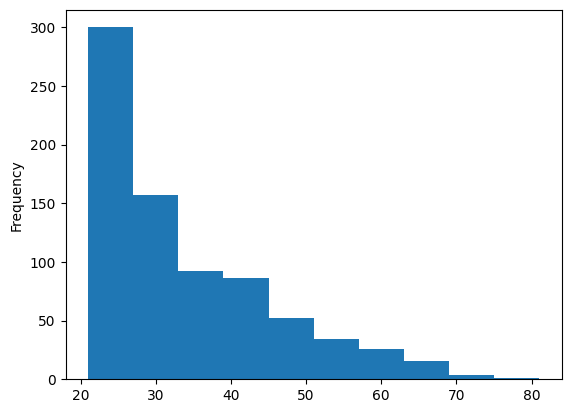

In [9]:
# make a histogram of the Age column
diabetes_df["Age"].plot.hist()

<Axes: xlabel='Age', ylabel='BloodPressure'>

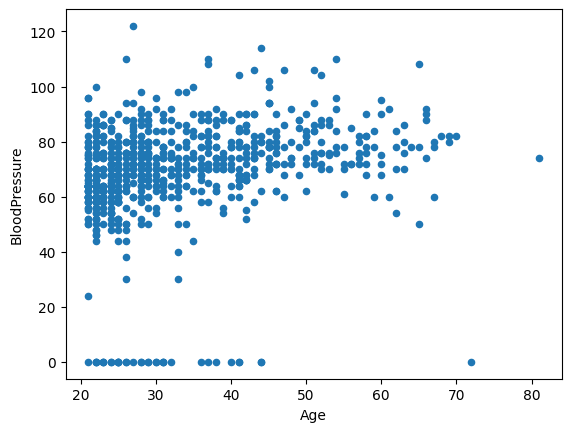

In [10]:
# make a plot of the Age column vs. the BloodPressure column
diabetes_df.plot.scatter(x='Age', y='BloodPressure')

### Identifying Missing Values
Zero values in 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI' indicate missing data. We need to handle these appropriately.


In [11]:
# Important: Leave this code in the notebook. It replaces the 0 values in the Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns with NaN
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_df[cols_with_zeros] = diabetes_df[cols_with_zeros].replace(0, np.nan)

In [12]:
# Assert Missing Values Handled (Code)
for col in cols_with_zeros:
    assert diabetes_df[col].min() > 0, f"Zero values not replaced in {col}"


### Removing rows with missing data

In [13]:
# make a copy of the dataframe called diabetes_df_dropped without rows with NaN values
diabetes_df_dropped = diabetes_df.dropna()
diabetes_df_dropped

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
753,0,181.0,88.0,44.0,510.0,43.3,0.222,26,1
755,1,128.0,88.0,39.0,110.0,36.5,1.057,37,1
760,2,88.0,58.0,26.0,16.0,28.4,0.766,22,0
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0


In [14]:
assert diabetes_df_dropped.isnull().sum().sum() == 0, "DataFrame still contains NaN values after dropping."
assert diabetes_df_dropped.shape[0] == 392, "DataFrame has incorrect shape after dropping."

### Replace the missing data with column averages

In [15]:
# make a copy of the dataframe called diabetes_df_filled with missing values filled in with the average value from the column
diabetes_df_filled = diabetes_df.copy()

for col in diabetes_df_filled.columns:
    print(f"column name: {col}")
    running_sum = 0
    count = 0

    
    for val in diabetes_df_dropped[col]:
        if pd.notna(val):
            running_sum += val
            count += 1

    if count > 0:
        col_avg = running_sum/count  
        print(f"column average: {col_avg}") 
        diabetes_df_filled[col] = diabetes_df_filled[col].fillna(col_avg)



column name: Pregnancies
column average: 3.3010204081632653
column name: Glucose
column average: 122.62755102040816
column name: BloodPressure
column average: 70.66326530612245
column name: SkinThickness
column average: 29.145408163265305
column name: Insulin
column average: 156.05612244897958
column name: BMI
column average: 33.086224489795896
column name: DiabetesPedigreeFunction
column average: 0.5230459183673473
column name: Age
column average: 30.864795918367346
column name: Outcome
column average: 0.33163265306122447


In [16]:
assert diabetes_df_filled.isnull().sum().sum() == 0, "DataFrame still contains NaN values after filling."
assert diabetes_df_filled.shape[0] == 768, "DataFrame has incorrect shape after filling."

### Forward fill and backward filling missing data

In [17]:
# make a copy of the dataframe called diabetes_df_ffill with missing values filled in using forward fill
diabetes_df_ffill = diabetes_df.ffill()
diabetes_df_ffill


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,29.0,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,180.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,23.0,112.0,30.1,0.349,47,1


In [18]:
# Check if the value after NaN is the same as the last known value before NaN for a specific column
column_to_check = 'Glucose'
# Find the first instance where ffill should have an effect
nan_index = diabetes_df[column_to_check].isnull().idxmax()  # First NaN index
if nan_index > 0:  # Ensure there's at least one non-NaN value before
    expected_value = diabetes_df_ffill[column_to_check][nan_index - 1]
    filled_value = diabetes_df_ffill[column_to_check][nan_index]
    assert expected_value == filled_value, "Forward fill did not work as expected"


In [19]:
# make a copy of the dataframe called diabetes_df_bfill with missing values filled in using backward fill
diabetes_df_bfill = diabetes_df.bfill()
diabetes_df_bfill


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,94.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,94.0,26.6,0.351,31,0
2,8,183.0,64.0,23.0,94.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,112.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,31.0,NaN,30.1,0.349,47,1


In [20]:
# Check if the value before NaN is the same as the next known value after NaN for a specific column
column_to_check = 'BloodPressure'
# Find the last instance where bfill should have an effect
nan_index = diabetes_df[column_to_check].isnull()[::-1].idxmax()  # Last NaN index
if nan_index < len(diabetes_df) - 1:  # Ensure there's at least one non-NaN value after
    expected_value = diabetes_df_bfill[column_to_check][nan_index + 1]
    filled_value = diabetes_df_bfill[column_to_check][nan_index]
    assert expected_value == filled_value, "Backward fill did not work as expected"


### Interpolate the missing values

In [21]:
# make a copy of the dataframe called diabetes_df_interpolated with missing values interpolated
diabetes_df_interpolated = diabetes_df.interpolate()
diabetes_df_interpolated



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,26.0,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,146.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,27.0,112.0,30.1,0.349,47,1


## Feature Engineering
Consider creating new features that may be helpful for your models. For example, let's create a feature that represents the interaction between BMI and Age since it may be predictive of diabetes.


In [22]:
# create a new column called BMI_Age that is the product of the BMI and Age columns

BMI_AGE_list = [a * b for a, b in zip(diabetes_df["Age"], diabetes_df["BMI"])]

BMI_AGE_list

diabetes_df["BMI_Age"] = BMI_AGE_list



In [23]:
assert 'BMI_Age' in diabetes_df.columns, "Interaction feature BMI_Age not created"